# Stage 3: Inverse Design

This notebook implements the full Stage 3 pipeline:

```
Target properties q*
        │
        ▼
  z ~ N(0, I)  +  q*  ──►  CVAE Decoder  ──►  Point cloud P̂
                                                     │
                                          Fit neural SDF  S_θ̂(x)
                                                     │
                                          FlexiCubes (differentiable)
                                                     │
                                             Mesh  M = (V, F)
                                                     │
                                    Evaluate properties  q̂ = (f₁, f₂, f₃, f₄)
                                                     │
                                    PSE = ‖q̂ - q*‖₂
```

**Dependencies:**  
```
pip install torch open3d scikit-image trimesh numpy matplotlib
```

**Interface with Stage 2:**  
This notebook loads the CVAE checkpoint saved by the Stage 2 notebook (`cvae_checkpoint.pt`).  
Set `CHECKPOINT_PATH` in Cell 2 to point to your saved checkpoint.

## 1. Imports & Setup

In [ ]:
!pip install torch open3d scikit-image trimesh numpy matplotlib

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys
import open3d as o3d
import trimesh
import os
from pathlib import Path

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Output directory for saved meshes
MESH_DIR = Path('generated_meshes')
MESH_DIR.mkdir(exist_ok=True)
print(f'Meshes will be saved to: {MESH_DIR.resolve()}')

Using device: cuda
Meshes will be saved to: /content/generated_meshes


## 2. Configuration

Set `CHECKPOINT_PATH` to your Stage 2 checkpoint.  
All other dimensions are loaded automatically from the checkpoint config.

In [ ]:
# --- Stage 2 checkpoint ---
CHECKPOINT_PATH = 'cvae_checkpoint.pt'  # <-- update this path

# --- Stage 3 settings ---
N_SAMPLES   = 10       # number of shapes to generate per target property vector
GRID_RES    = 128      # FlexiCubes grid resolution (use 128 for higher fidelity)
GRID_EXTENT = 1.5     # bounding box half-extent for the SDF grid

# --- SDF fitting settings ---
SDF_EPOCHS  = 1000    # iterations to fit neural SDF to generated point cloud
SDF_LR      = 5e-4
SDF_HIDDEN  = 512
SDF_LAYERS  = 8
LAMBDA_EIK  = 0.1     # Eikonal regularisation weight

# --- PSE evaluation ---
# Properties: [volume, surface_area, curvature, other]  (k=4, matching Stage 2)
PROP_NAMES  = ['Volume', 'Surface Area']
TAU_VOL     = 0.01    # soft occupancy temperature for volume
TAU_AREA    = 0.01    # Gaussian kernel bandwidth for surface area

print('Configuration set.')

Configuration set.


## 3. Load CVAE from Stage 2

We rebuild the exact same CVAE architecture from Stage 2 and load the saved weights.  
Only the **decoder** is used at inference — the encoder is discarded.

In [ ]:
# ── Rebuild the Stage 2 CVAE architecture ────────────────────────────────────

class Encoder(nn.Module):
    """(properties, point_cloud) -> (mu, logvar)  [used only at training time]"""
    def __init__(self, prop_dim, pc_dim, hidden_dim, z_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(prop_dim + pc_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim,        hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(hidden_dim, z_dim)
        self.fc_logvar = nn.Linear(hidden_dim, z_dim)

    def forward(self, properties, point_cloud):
        pc_flat = point_cloud.view(point_cloud.size(0), -1)
        h = self.net(torch.cat([properties, pc_flat], dim=-1))
        return self.fc_mu(h), self.fc_logvar(h)


class Decoder(nn.Module):
    """(z, properties) -> point_cloud  [the generative model]"""
    def __init__(self, z_dim, prop_dim, hidden_dim, pc_dim, n_points, point_dim=3):
        super().__init__()
        self.n_points  = n_points
        self.point_dim = point_dim
        self.net = nn.Sequential(
            nn.Linear(z_dim + prop_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim,       hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim,       pc_dim),
        )

    def forward(self, z, properties):
        out = self.net(torch.cat([z, properties], dim=-1))
        return out.view(out.size(0), self.n_points, self.point_dim)


class CVAE(nn.Module):
    def __init__(self, prop_dim, n_points, point_dim=3, hidden_dim=512, z_dim=128):
        super().__init__()
        pc_dim = n_points * point_dim
        self.encoder = Encoder(prop_dim, pc_dim, hidden_dim, z_dim)
        self.decoder = Decoder(z_dim, prop_dim, hidden_dim, pc_dim, n_points, point_dim)
        self.z_dim   = z_dim

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, properties, point_cloud):
        mu, logvar = self.encoder(properties, point_cloud)
        z          = self.reparameterize(mu, logvar)
        return self.decoder(z, properties), mu, logvar

    @torch.no_grad()
    def generate(self, properties, n_samples=1):
        """Inverse design: sample z ~ N(0,I), decode -> point cloud."""
        self.eval()
        if properties.dim() == 1:
            properties = properties.unsqueeze(0).expand(n_samples, -1)
        z = torch.randn(n_samples, self.z_dim, device=properties.device)
        return self.decoder(z, properties)   # (n_samples, N_POINTS, 3)


# ── Load checkpoint ───────────────────────────────────────────────────────────
if os.path.exists(CHECKPOINT_PATH):
    ckpt   = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    config = ckpt['config']
    model  = CVAE(
        prop_dim   = config['prop_dim'],
        n_points   = config['n_points'],
        point_dim  = config['point_dim'],
        hidden_dim = config['hidden_dim'],
        z_dim      = config['z_dim'],
    ).to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    PROP_DIM = config['prop_dim']
    N_POINTS = config['n_points']
    Z_DIM    = config['z_dim']
    print(f'Loaded CVAE from {CHECKPOINT_PATH}')
    print(f'  prop_dim={PROP_DIM}, n_points={N_POINTS}, z_dim={Z_DIM}')
else:
    # ── MOCK decoder for development (no checkpoint yet) ─────────────────────
    print(f'[WARNING] Checkpoint not found at {CHECKPOINT_PATH}.')
    print('[WARNING] Using a MOCK decoder that outputs sphere-like point clouds.')
    print('[WARNING] Replace with real checkpoint once Stage 2 is trained.')

    PROP_DIM = 2
    N_POINTS = 1024
    Z_DIM    = 128

    model = CVAE(
        prop_dim   = PROP_DIM,
        n_points   = N_POINTS,
        point_dim  = 3,
        hidden_dim = 512,
        z_dim      = Z_DIM,
    ).to(DEVICE)

    # Override the decoder with one that outputs a noisy sphere so the full
    # pipeline (SDF fitting, FlexiCubes, PSE) can be tested end-to-end.
    class MockDecoder(nn.Module):
        def __init__(self, n_points, z_dim, prop_dim):
            super().__init__()
            self.n_points = n_points
            self.z_dim    = z_dim

        def forward(self, z, properties):
            B = z.size(0)
            pts = torch.randn(B, self.n_points, 3, device=z.device)
            pts = F.normalize(pts, dim=-1)

            # Volume ~ radius³, so radius ∝ cbrt(volume property)
            radius = 0.2 + 0.6 * properties[:, 0:1] ** (1/3)

            # Surface area: add spiky noise proportional to surface_area property
            # higher surface area = more irregular surface
            spikiness = properties[:, 1:2]
            noise = torch.randn_like(pts) * 0.05 * spikiness.unsqueeze(1)

            # Curvature: bend the sphere by offsetting along one axis
            curvature_bend = properties[:, 2:3].unsqueeze(1) * pts[:, :, 0:1] * 0.3

            pts = pts * radius.unsqueeze(1) + noise + curvature_bend
            pts += 0.01 * torch.randn_like(pts)  # small base noise
            return pts

    model.decoder = MockDecoder(N_POINTS, Z_DIM, PROP_DIM).to(DEVICE)
    model.eval()


Loaded CVAE from cvae_checkpoint.pt
  prop_dim=2, n_points=1024, z_dim=64


## 4. Define Target Property Vectors

Each row is one target $\mathbf{q}^* \in [0,1]^4$.  
Properties are: `[Volume, Surface Area, Curvature, Other]` — all normalised to $[0,1]$.

In [ ]:
# Define target property vectors — [volume, surface_area] all in [0, 1]
target_properties = torch.tensor([
    [0.3, 0.7],   # low volume, high surface area
    [0.7, 0.3],   # high volume, low surface area
    [0.5, 0.5],   # balanced trade-off
    [0.1, 0.9],   # minimal volume, maximal area
    [0.9, 0.1],   # maximal volume, minimal area
], dtype=torch.float32).to(DEVICE)

print(f'Number of design targets: {len(target_properties)}')
print(f'Property names: {PROP_NAMES}')
print()
for i, q in enumerate(target_properties):
    vals = ', '.join(f'{n}={v:.2f}' for n, v in zip(PROP_NAMES, q.tolist()))
    print(f'  Target {i+1}: {vals}')

Number of design targets: 5
Property names: ['Volume', 'Surface Area']

  Target 1: Volume=0.30, Surface Area=0.70
  Target 2: Volume=0.70, Surface Area=0.30
  Target 3: Volume=0.50, Surface Area=0.50
  Target 4: Volume=0.10, Surface Area=0.90
  Target 5: Volume=0.90, Surface Area=0.10


## 5. Generate Point Clouds

For each target $\mathbf{q}^*$, sample `N_SAMPLES` latent codes $z \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and decode.

In [ ]:
def generate_point_clouds(model, q_star, n_samples, device):
    """
    Generate n_samples point clouds for a single target property vector q_star.

    Parameters
    ----------
    model     : trained CVAE
    q_star    : (PROP_DIM,)  target property vector
    n_samples : int

    Returns
    -------
    point_clouds : (n_samples, N_POINTS, 3)  numpy array
    """
    model.eval()
    with torch.no_grad():
        pcs = model.generate(q_star.to(device), n_samples=n_samples)
    return pcs.cpu().numpy()   # (n_samples, N_POINTS, 3)


# Generate for all targets
all_point_clouds = {}   # {target_idx: (n_samples, N_POINTS, 3)}

for t_idx, q_star in enumerate(target_properties):
    pcs = generate_point_clouds(model, q_star, N_SAMPLES, DEVICE)
    all_point_clouds[t_idx] = pcs
    print(f'Target {t_idx+1}: generated {N_SAMPLES} point clouds, shape {pcs.shape}')

print('\nAll point clouds generated.')

Target 1: generated 10 point clouds, shape (10, 1024, 3)
Target 2: generated 10 point clouds, shape (10, 1024, 3)
Target 3: generated 10 point clouds, shape (10, 1024, 3)
Target 4: generated 10 point clouds, shape (10, 1024, 3)
Target 5: generated 10 point clouds, shape (10, 1024, 3)

All point clouds generated.


## 6. Visualise Generated Point Clouds

Quick matplotlib preview of the first generated shape per target.  
For interactive inspection, use `visualise_open3d()` defined below.

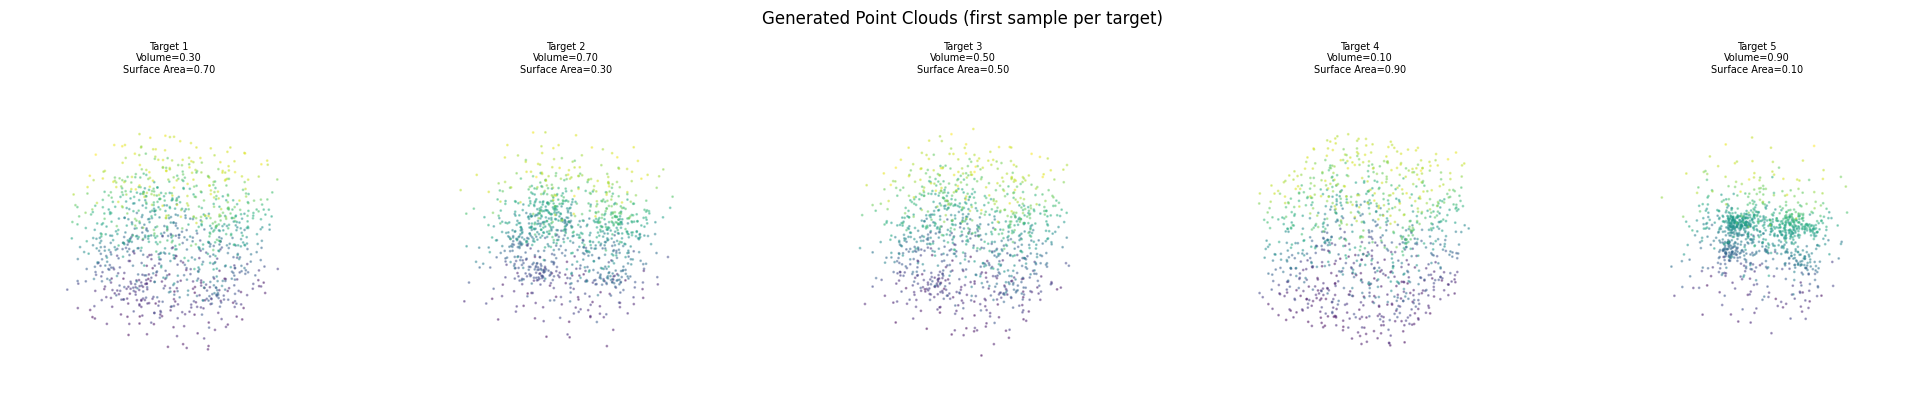

Saved: generated_point_clouds.png


In [ ]:
def plot_point_cloud_grid(all_point_clouds, target_properties, prop_names, n_cols=5):
    """Plot the first generated point cloud for each target in a grid."""
    n_targets = len(all_point_clouds)
    n_rows    = (n_targets + n_cols - 1) // n_cols
    fig       = plt.figure(figsize=(4 * n_cols, 4 * n_rows))

    for t_idx in range(n_targets):
        pc  = all_point_clouds[t_idx][0]   # first sample, (N_POINTS, 3)
        q   = target_properties[t_idx].cpu().numpy()
        ax  = fig.add_subplot(n_rows, n_cols, t_idx + 1, projection='3d')
        ax.scatter(pc[:, 0], pc[:, 1], pc[:, 2], s=1, alpha=0.4, c=pc[:, 2], cmap='viridis')
        ax.set_title(
            f'Target {t_idx+1}\n' +
            '\n'.join(f'{prop_names[j]}={q[j]:.2f}' for j in range(len(q))),
            fontsize=7
        )
        ax.set_box_aspect([1,1,1])
        ax.set_axis_off()

    plt.suptitle('Generated Point Clouds (first sample per target)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('generated_point_clouds.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: generated_point_clouds.png')


plot_point_cloud_grid(all_point_clouds, target_properties, PROP_NAMES)


def visualise_open3d(point_cloud_np, title='Generated Point Cloud'):
    """
    Open an interactive Open3D window to inspect a single point cloud.
    Call this manually in a cell for interactive use.

    point_cloud_np : (N, 3) numpy array
    """
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(point_cloud_np)
    pcd.estimate_normals()
    o3d.visualization.draw_geometries([pcd], window_name=title,
                                      width=800, height=600)

# Example interactive call (uncomment to use):
# visualise_open3d(all_point_clouds[0][0], title='Target 1 - Sample 1')

## 7. Neural SDF Fitting

For each generated point cloud $\hat{P}$, fit a DeepSDF-style network $S_{\hat{\theta}}(\mathbf{x})$
by minimising:
$$\mathcal{L}_\text{fit} = \underbrace{\frac{1}{|\hat{P}|}\sum_{\mathbf{x}\in\hat{P}} S_{\hat{\theta}}(\mathbf{x})^2}_{\text{on-surface: }S=0} + \lambda_\text{eik}\,\mathcal{L}_\text{eik}(\hat{\theta})$$

In [ ]:
class DeepSDFNet(nn.Module):
    """
    DeepSDF-style neural SDF network.
    8 layers, softplus activations, skip connection from input to layer 5.
    """
    def __init__(self, hidden_dim=512):
        super().__init__()
        self.fc1 = nn.Linear(3,              hidden_dim)
        self.fc2 = nn.Linear(hidden_dim,     hidden_dim)
        self.fc3 = nn.Linear(hidden_dim,     hidden_dim)
        self.fc4 = nn.Linear(hidden_dim,     hidden_dim)
        # skip: re-inject input at layer 5
        self.fc5 = nn.Linear(hidden_dim + 3, hidden_dim)
        self.fc6 = nn.Linear(hidden_dim,     hidden_dim)
        self.fc7 = nn.Linear(hidden_dim,     hidden_dim)
        self.fc8 = nn.Linear(hidden_dim,     hidden_dim)
        self.out = nn.Linear(hidden_dim,     1)
        self.act = nn.Softplus(beta=100)

    def forward(self, x):
        inp = x
        h   = self.act(self.fc1(x))
        h   = self.act(self.fc2(h))
        h   = self.act(self.fc3(h))
        h   = self.act(self.fc4(h))
        h   = torch.cat([h, inp], dim=-1)    # skip connection
        h   = self.act(self.fc5(h))
        h   = self.act(self.fc6(h))
        h   = self.act(self.fc7(h))
        h   = self.act(self.fc8(h))
        return self.out(h)                   # (B, 1)


def eikonal_loss(sdf_net, points, n_samples=2048, device='cpu'):
    """Penalise ||∇S|| ≠ 1 on random points in the bounding volume."""
    x = (torch.rand(n_samples, 3, device=device) * 2 - 1) * GRID_EXTENT
    x.requires_grad_(True)
    s = sdf_net(x)
    grad = torch.autograd.grad(s.sum(), x, create_graph=True)[0]
    return ((grad.norm(dim=-1) - 1) ** 2).mean()


def fit_sdf(point_cloud_np, epochs=SDF_EPOCHS, lr=SDF_LR,
            lambda_eik=LAMBDA_EIK, hidden_dim=SDF_HIDDEN,
            device=DEVICE, verbose=True):
    """
    Fit a DeepSDF network to a generated point cloud.

    Parameters
    ----------
    point_cloud_np : (N, 3) numpy array  — on-surface points

    Returns
    -------
    sdf_net : trained DeepSDFNet
    losses  : list of total loss values
    """
    sdf_net = DeepSDFNet(hidden_dim=hidden_dim).to(device)
    opt     = torch.optim.Adam(sdf_net.parameters(), lr=lr)

    pts_surf = torch.tensor(point_cloud_np, dtype=torch.float32, device=device)

    n_off  = len(pts_surf)
    pts_off = (torch.rand(n_off, 3, device=device) * 2 - 1) * GRID_EXTENT

    dists_unsigned = torch.cdist(pts_off, pts_surf).min(dim=1).values
    centroid = pts_surf.mean(dim=0, keepdim=True)
    mean_surf_radius = torch.cdist(centroid, pts_surf).mean()
    dist_to_centroid = torch.norm(pts_off - centroid, dim=-1)
    sign = torch.where(dist_to_centroid < mean_surf_radius, -1.0, 1.0)
    dists = sign * dists_unsigned   # signed distance approximation

    losses = []
    sdf_net.train()

    for epoch in range(1, epochs + 1):
        opt.zero_grad()

        # --- On-surface loss: S(x) = 0 ---
        s_surf = sdf_net(pts_surf)               # (N, 1)
        loss_surf = (s_surf ** 2).mean()

        # --- Off-surface loss: S(x) ≈ dist ---
        s_off = sdf_net(pts_off)                 # (n_off, 1)
        loss_off = F.mse_loss(s_off.squeeze(), dists)

        # --- Eikonal loss ---
        loss_eik = eikonal_loss(sdf_net, pts_surf, device=device)

        loss = loss_surf + 0.5 * loss_off + lambda_eik * loss_eik
        loss.backward()
        opt.step()

        losses.append(loss.item())
        if verbose and epoch % 200 == 0:
            print(f'  [{epoch}/{epochs}] loss={loss.item():.5f}  '
                  f'surf={loss_surf.item():.5f}  '
                  f'eik={loss_eik.item():.5f}')

    sdf_net.eval()
    return sdf_net, losses


print('DeepSDF fitting functions defined.')

DeepSDF fitting functions defined.


In [ ]:
# Fit SDF for all generated point clouds
# Dictionary structure: {target_idx: [sdf_net_sample_0, sdf_net_sample_1, ...]}
all_sdf_nets   = {}
all_sdf_losses = {}

for t_idx in range(len(target_properties)):
    all_sdf_nets[t_idx]   = []
    all_sdf_losses[t_idx] = []
    print(f'\n=== Fitting SDF for Target {t_idx+1}/{len(target_properties)} ===')

    for s_idx in range(N_SAMPLES):
        pc = all_point_clouds[t_idx][s_idx]   # (N_POINTS, 3)
        print(f'  Sample {s_idx+1}/{N_SAMPLES}:')
        sdf_net, losses = fit_sdf(pc, verbose=True)
        all_sdf_nets[t_idx].append(sdf_net)
        all_sdf_losses[t_idx].append(losses)

print('\nAll SDF networks fitted.')


=== Fitting SDF for Target 1/5 ===
  Sample 1/10:
  [200/1000] loss=0.00323  surf=0.00128  eik=0.01593
  [400/1000] loss=0.00253  surf=0.00083  eik=0.01304
  [600/1000] loss=0.00173  surf=0.00082  eik=0.00614
  [800/1000] loss=0.00173  surf=0.00077  eik=0.00525
  [1000/1000] loss=0.00262  surf=0.00102  eik=0.01049
  Sample 2/10:
  [200/1000] loss=0.00333  surf=0.00142  eik=0.01552
  [400/1000] loss=0.00240  surf=0.00086  eik=0.01272
  [600/1000] loss=0.00215  surf=0.00115  eik=0.00617
  [800/1000] loss=0.00240  surf=0.00094  eik=0.01085
  [1000/1000] loss=0.00193  surf=0.00090  eik=0.00730
  Sample 3/10:
  [200/1000] loss=0.00344  surf=0.00142  eik=0.01688
  [400/1000] loss=0.00369  surf=0.00110  eik=0.01323
  [600/1000] loss=0.00202  surf=0.00101  eik=0.00700
  [800/1000] loss=0.00260  surf=0.00077  eik=0.01371
  [1000/1000] loss=0.00229  surf=0.00082  eik=0.00895
  Sample 4/10:
  [200/1000] loss=0.00374  surf=0.00127  eik=0.02164
  [400/1000] loss=0.00242  surf=0.00108  eik=0.01037


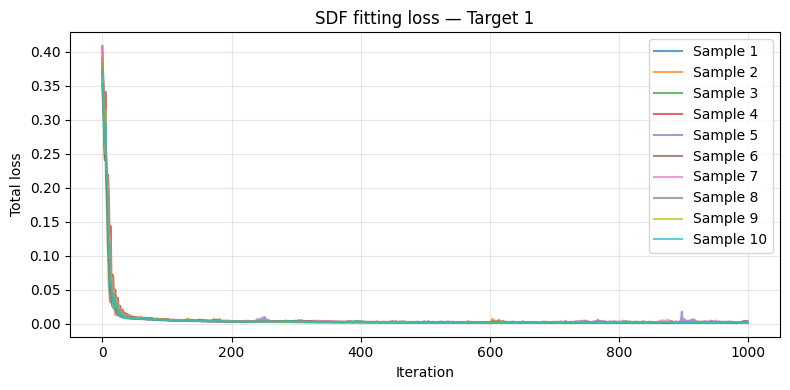

Saved: sdf_fitting_loss.png


In [ ]:
# Plot SDF fitting loss curves for the first target
fig, ax = plt.subplots(figsize=(8, 4))
for s_idx in range(N_SAMPLES):
    ax.plot(all_sdf_losses[0][s_idx], alpha=0.7, label=f'Sample {s_idx+1}')
ax.set_xlabel('Iteration')
ax.set_ylabel('Total loss')
ax.set_title('SDF fitting loss — Target 1')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sdf_fitting_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sdf_fitting_loss.png')

## 8. FlexiCubes — Extract Meshes

Evaluate the fitted SDF on a regular $R^3$ grid and extract the zero level set $\{S_{\hat{\theta}}=0\}$ using FlexiCubes, a differentiable isosurface extraction method that produces higher-quality meshes than Marching Cubes.

In [ ]:
def evaluate_sdf_on_grid(sdf_net, grid_res, extent, device, batch_size=32768):
    """
    Evaluate the SDF on a regular 3D grid.

    Returns
    -------
    grid : (R, R, R) numpy array of SDF values
    sdf_tensor : (R*R*R,) torch.Tensor of SDF values (kept on device for FlexiCubes)
    """
    lin   = np.linspace(-extent, extent, grid_res)
    gx, gy, gz = np.meshgrid(lin, lin, lin, indexing='ij')
    coords = np.stack([gx.ravel(), gy.ravel(), gz.ravel()], axis=-1).astype(np.float32)

    sdf_vals = []
    sdf_net.eval()
    with torch.no_grad():
        for i in range(0, len(coords), batch_size):
            batch = torch.tensor(coords[i:i+batch_size], device=device)
            sdf_vals.append(sdf_net(batch).squeeze(-1).cpu())

    sdf_tensor = torch.cat(sdf_vals)          # (R^3,) on CPU
    grid = sdf_tensor.numpy().reshape(grid_res, grid_res, grid_res)
    return grid, sdf_tensor


from skimage.measure import marching_cubes

def extract_mesh(sdf_net, grid_res=GRID_RES, extent=GRID_EXTENT, device=DEVICE):
    """
    Extract a triangle mesh from a neural SDF via Marching Cubes (skimage).
    This matches the paper's Section 6.4 specification exactly.
    """
    grid, _ = evaluate_sdf_on_grid(sdf_net, grid_res, extent, device)

    if grid.min() > 0 or grid.max() < 0:
        print('  [WARNING] Zero level set not present in grid — shape may be degenerate.')
        return None, None, grid

    voxel_size = (2 * extent) / (grid_res - 1)

    verts, faces, normals, _ = marching_cubes(
        grid,
        level=0.0,
        spacing=(voxel_size, voxel_size, voxel_size)
    )

    # marching_cubes returns verts in voxel units starting from 0,
    # shift to centre at origin to match the SDF's [-extent, extent]^3 domain
    verts = verts - extent

    return verts, faces, grid


def save_mesh_obj(verts, faces, filepath):
    """Save a triangle mesh as a Wavefront .obj file."""
    with open(filepath, 'w') as f:
        f.write('# Generated by Stage 3 Inverse Design Pipeline (Marching Cubes)\n')
        for v in verts:
            f.write(f'v {v[0]:.6f} {v[1]:.6f} {v[2]:.6f}\n')
        for face in faces:
            f.write(f'f {face[0]+1} {face[1]+1} {face[2]+1}\n')

print('Mesh extraction functions defined (Marching Cubes).')

Mesh extraction functions defined (Marching Cubes).


In [ ]:
# Extract meshes for all SDF networks
# Dictionary structure: {target_idx: [(verts, faces), ...]}
all_meshes = {}

for t_idx in range(len(target_properties)):
    all_meshes[t_idx] = []
    print(f'\n=== FlexiCubes — Target {t_idx+1}/{len(target_properties)} ===')

    for s_idx, sdf_net in enumerate(all_sdf_nets[t_idx]):
        verts, faces, grid = extract_mesh(sdf_net)

        if verts is not None:
            all_meshes[t_idx].append((verts, faces))

            # Save as .obj
            fname = MESH_DIR / f'target{t_idx+1}_sample{s_idx+1}.obj'
            save_mesh_obj(verts, faces, fname)
            print(f'  Sample {s_idx+1}: {len(verts):,} verts, {len(faces):,} faces → {fname}')
        else:
            all_meshes[t_idx].append(None)
            print(f'  Sample {s_idx+1}: [degenerate — skipped]')

print('\nAll meshes extracted and saved.')


=== FlexiCubes — Target 1/5 ===
  Sample 1: 34,217 verts, 68,494 faces → generated_meshes/target1_sample1.obj
  Sample 2: 32,901 verts, 65,834 faces → generated_meshes/target1_sample2.obj
  Sample 3: 46,102 verts, 92,256 faces → generated_meshes/target1_sample3.obj
  Sample 4: 25,590 verts, 51,172 faces → generated_meshes/target1_sample4.obj
  Sample 5: 29,736 verts, 59,452 faces → generated_meshes/target1_sample5.obj
  Sample 6: 33,899 verts, 67,894 faces → generated_meshes/target1_sample6.obj
  Sample 7: 42,410 verts, 84,876 faces → generated_meshes/target1_sample7.obj
  Sample 8: 32,814 verts, 65,700 faces → generated_meshes/target1_sample8.obj
  Sample 9: 31,819 verts, 63,662 faces → generated_meshes/target1_sample9.obj
  Sample 10: 25,121 verts, 50,278 faces → generated_meshes/target1_sample10.obj

=== FlexiCubes — Target 2/5 ===
  Sample 1: 29,812 verts, 59,632 faces → generated_meshes/target2_sample1.obj
  Sample 2: 27,417 verts, 54,870 faces → generated_meshes/target2_sample2.

## 9. Visualise Meshes

Matplotlib preview of the first mesh per target.  
Use `visualise_mesh_open3d()` for interactive inspection.

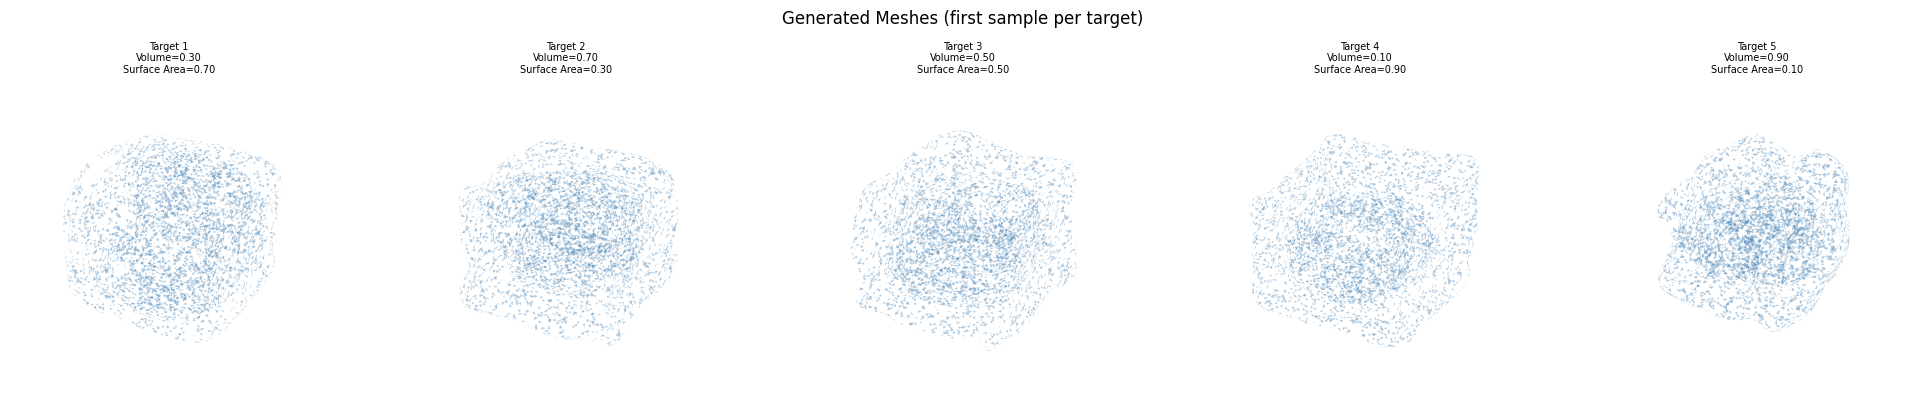

Saved: generated_meshes_preview.png
[Open3D WARNING] GLFW Error: Failed to detect any supported platform
[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.


In [ ]:
def plot_mesh_grid(all_meshes, target_properties, prop_names, n_cols=5):
    """Plot first mesh per target as a 3D triangle surface."""
    n_targets = len(all_meshes)
    n_rows    = (n_targets + n_cols - 1) // n_cols
    fig       = plt.figure(figsize=(4 * n_cols, 4 * n_rows))

    from mpl_toolkits.mplot3d.art3d import Poly3DCollection

    for t_idx in range(n_targets):
        mesh = all_meshes[t_idx][0] if all_meshes[t_idx] else None
        q    = target_properties[t_idx].cpu().numpy()
        ax   = fig.add_subplot(n_rows, n_cols, t_idx + 1, projection='3d')

        if mesh is not None:
            verts, faces = mesh
            # Subsample faces for speed
            idx  = np.random.choice(len(faces), min(5000, len(faces)), replace=False)
            tris = verts[faces[idx]]
            poly = Poly3DCollection(tris, alpha=0.4, linewidth=0,
                                    facecolor='steelblue', edgecolor='none')
            ax.add_collection3d(poly)
            ax.auto_scale_xyz(verts[:,0], verts[:,1], verts[:,2])
        else:
            ax.text(0.5, 0.5, 0.5, 'degenerate', ha='center', va='center',
                    transform=ax.transAxes, color='red')

        ax.set_title(
            f'Target {t_idx+1}\n' +
            '\n'.join(f'{prop_names[j]}={q[j]:.2f}' for j in range(len(q))),
            fontsize=7
        )
        ax.set_axis_off()

    plt.suptitle('Generated Meshes (first sample per target)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('generated_meshes_preview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: generated_meshes_preview.png')


plot_mesh_grid(all_meshes, target_properties, PROP_NAMES)


def visualise_mesh_open3d(verts, faces, title='Generated Mesh'):
    """
    Interactive Open3D mesh viewer. Call manually in a cell.

    verts : (V, 3) numpy array
    faces : (F, 3) numpy array
    """
    mesh = o3d.geometry.TriangleMesh()
    mesh.vertices  = o3d.utility.Vector3dVector(verts)
    mesh.triangles = o3d.utility.Vector3iVector(faces)
    mesh.compute_vertex_normals()
    mesh.paint_uniform_color([0.3, 0.6, 0.9])
    o3d.visualization.draw_geometries([mesh], window_name=title,
                                      width=800, height=600)


if all_meshes[0] and all_meshes[0][0] is not None:
    v, f = all_meshes[0][0]
    visualise_mesh_open3d(v, f, title='Target 1 - Sample 1')
else:
    print('[WARNING] First mesh is degenerate — skipping interactive visualisation.')

## 10. Differentiable Property Evaluation

Compute the true property vector $\hat{\mathbf{q}} = (f_1, f_2, f_3, f_4)$ for each
generated shape directly from the fitted SDF $S_{\hat{\theta}}$.

| Property | Estimator |
|---|---|
| Volume | $\tilde{f}_\text{vol} = \|\mathcal{B}\| \cdot \frac{1}{M}\sum_m \sigma(-S/\tau)$ |
| Surface area | $\tilde{f}_\text{area} = \|\mathcal{B}\| \cdot \frac{1}{M}\sum_m \delta_\tau(S)\|\nabla S\|$ |
| Curvature | $\tilde{f}_\text{curv} = \frac{1}{M}\sum_m \delta_\tau(S)\,\kappa^2$ |
| Other (proxy) | Mean absolute SDF value near surface |


In [ ]:
def compute_properties(sdf_net, n_samples=50000, tau=TAU_VOL,
                        extent=GRID_EXTENT, device=DEVICE):
    """
    Estimate all 2 geometric properties from a fitted SDF network.

    Returns
    -------
    props : dict with keys 'volume', 'surface_area'
            all values are raw (un-normalised) floats
    """
    sdf_net.eval()

    # Sample random points in the bounding box
    x = (torch.rand(n_samples, 3, device=device) * 2 - 1) * extent
    x.requires_grad_(True)

    s = sdf_net(x)                  # (N, 1)
    s_flat = s.squeeze(-1)          # (N,)

    # Gradient ∇S w.r.t. x (for surface area and curvature)
    grad = torch.autograd.grad(
        s.sum(), x, create_graph=True
    )[0]                            # (N, 3)
    grad_norm = grad.norm(dim=-1)   # (N,)

    vol_box = (2 * extent) ** 3

    # ── Volume ──────────────────────────────────────────────────────────────
    soft_occ = torch.sigmoid(-s_flat / tau)
    volume   = vol_box * soft_occ.mean().item()

    # ── Surface area ────────────────────────────────────────────────────────
    delta    = (1.0 / (np.sqrt(2 * np.pi) * tau)) * \
               torch.exp(-0.5 * (s_flat / tau) ** 2)
    area     = vol_box * (delta * grad_norm).mean().item()

    # ── Curvature (mean curvatu
    return {
        'volume':       volume,
        'surface_area': area,
    }


print('Property evaluation function defined.')

Property evaluation function defined.


In [ ]:
# Compute properties for all generated shapes
# Structure: {target_idx: [props_sample_0, props_sample_1, ...]}
all_props = {}

for t_idx in range(len(target_properties)):
    all_props[t_idx] = []
    print(f'\nTarget {t_idx+1}:')
    for s_idx, sdf_net in enumerate(all_sdf_nets[t_idx]):
        props = compute_properties(sdf_net)
        all_props[t_idx].append(props)
        vals = ', '.join(f"{k}={v:.4f}" for k, v in props.items())
        print(f'  Sample {s_idx+1}: {vals}')

print('\nAll properties computed.')


Target 1:
  Sample 1: volume=0.9156, surface_area=14.6570, curvature=27939.2598, other=0.0136
  Sample 2: volume=1.0490, surface_area=13.3839, curvature=5023.0757, other=0.0145
  Sample 3: volume=1.0605, surface_area=18.6360, curvature=27418.9629, other=0.0138
  Sample 4: volume=0.9606, surface_area=10.7658, curvature=389.5409, other=0.0148
  Sample 5: volume=0.9963, surface_area=12.9041, curvature=1711.7144, other=0.0145
  Sample 6: volume=0.8390, surface_area=13.1323, curvature=6775.6260, other=0.0136
  Sample 7: volume=0.8856, surface_area=16.6120, curvature=30508.2344, other=0.0144
  Sample 8: volume=0.8433, surface_area=12.9500, curvature=5736.9907, other=0.0143
  Sample 9: volume=0.8758, surface_area=13.0483, curvature=13036.2744, other=0.0145
  Sample 10: volume=0.8872, surface_area=10.2659, curvature=1842.3767, other=0.0145

Target 2:
  Sample 1: volume=0.8194, surface_area=12.1965, curvature=2679.6274, other=0.0142
  Sample 2: volume=0.7313, surface_area=10.7453, curvature=18

## 11. Property Satisfaction Error (PSE)

$$\mathrm{PSE}(\hat{P}, \mathbf{q}^*) = \|\hat{\mathbf{q}} - \mathbf{q}^*\|_2$$

Before computing PSE we must **normalise** $\hat{\mathbf{q}}$ to $[0,1]$ using the same
normalisation statistics as Stage 1/2.  
Here we normalise across the generated shapes themselves (replace with Stage 1 statistics once available).

In [ ]:
PROP_KEYS = ['volume', 'surface_area']

# Collect all raw property values to compute normalisation statistics
raw_vals = {k: [] for k in PROP_KEYS}
for t_idx in all_props:
    for props in all_props[t_idx]:
        for k in PROP_KEYS:
            raw_vals[k].append(props[k])

prop_min = {k: min(raw_vals[k]) for k in PROP_KEYS}
prop_max = {k: max(raw_vals[k]) for k in PROP_KEYS}

print('Normalisation statistics (replace with Stage 1 stats once available):')
for k in PROP_KEYS:
    print(f'  {k:15s}: min={prop_min[k]:.4f}, max={prop_max[k]:.4f}')


def normalise_props(props_dict, prop_min, prop_max):
    """Normalise a property dict to [0,1] given min/max dicts."""
    normed = []
    for k in PROP_KEYS:
        denom = prop_max[k] - prop_min[k]
        normed.append(
            (props_dict[k] - prop_min[k]) / denom if denom > 1e-8 else 0.0
        )
    return np.array(normed, dtype=np.float32)


def compute_pse(q_hat_norm, q_star_norm):
    """PSE = ||q_hat - q*||_2"""
    return float(np.linalg.norm(q_hat_norm - q_star_norm))


def compute_pse_per_dim(q_hat_norm, q_star_norm):
    """Per-objective PSE_j = |q_hat_j - q*_j|"""
    return np.abs(q_hat_norm - q_star_norm)


print('\nPSE functions defined.')

Normalisation statistics (replace with Stage 1 stats once available):
  volume         : min=0.5432, max=1.2678
  surface_area   : min=6.9770, max=18.6360

PSE functions defined.


In [ ]:
# Compute PSE for all targets and samples
pse_table = []   # rows: (target_idx, sample_idx, PSE, PSE_per_dim)

print(f'{"Target":>8} {"Sample":>8} {"PSE":>10}  '
      + '  '.join(f'{n[:6]:>8}' for n in PROP_NAMES))
print('-' * 70)

for t_idx in range(len(target_properties)):
    q_star = target_properties[t_idx].cpu().numpy()

    for s_idx, props in enumerate(all_props[t_idx]):
        q_hat  = normalise_props(props, prop_min, prop_max)
        pse    = compute_pse(q_hat, q_star)
        pse_pd = compute_pse_per_dim(q_hat, q_star)
        pse_table.append((t_idx, s_idx, pse, pse_pd))

        print(f'{t_idx+1:>8} {s_idx+1:>8} {pse:>10.4f}  '
              + '  '.join(f'{v:>8.4f}' for v in pse_pd))

# Summary statistics
all_pse = [row[2] for row in pse_table]
print(f'\nMean PSE (all targets & samples): {np.mean(all_pse):.4f}')
print(f'Std  PSE:                          {np.std(all_pse):.4f}')
print(f'Min  PSE:                          {np.min(all_pse):.4f}')
print(f'Max  PSE:                          {np.max(all_pse):.4f}')

  Target   Sample        PSE    Volume    Surfac
----------------------------------------------------------------------
       1        1     0.2179    0.2140    0.0413
       1        2     0.4256    0.3981    0.1505
       1        3     0.5112    0.4139    0.3000
       1        4     0.4657    0.2761    0.3750
       1        5     0.3775    0.3253    0.1916
       1        6     0.2033    0.1082    0.1721
       1        7     0.2139    0.1725    0.1264
       1        8     0.2197    0.1141    0.1877
       1        9     0.2396    0.1590    0.1793
       1       10     0.4530    0.1747    0.4179
       2        1     0.3514    0.3189    0.1477
       2        2     0.4410    0.4403    0.0232
       2        3     0.3978    0.3970    0.0245
       2        4     0.5052    0.5046    0.0257
       2        5     0.3453    0.3451    0.0108
       2        6     0.5541    0.5515    0.0535
       2        7     0.5324    0.5296    0.0547
       2        8     0.7125    0.7000    0.132

## 12. PSE Visualisation

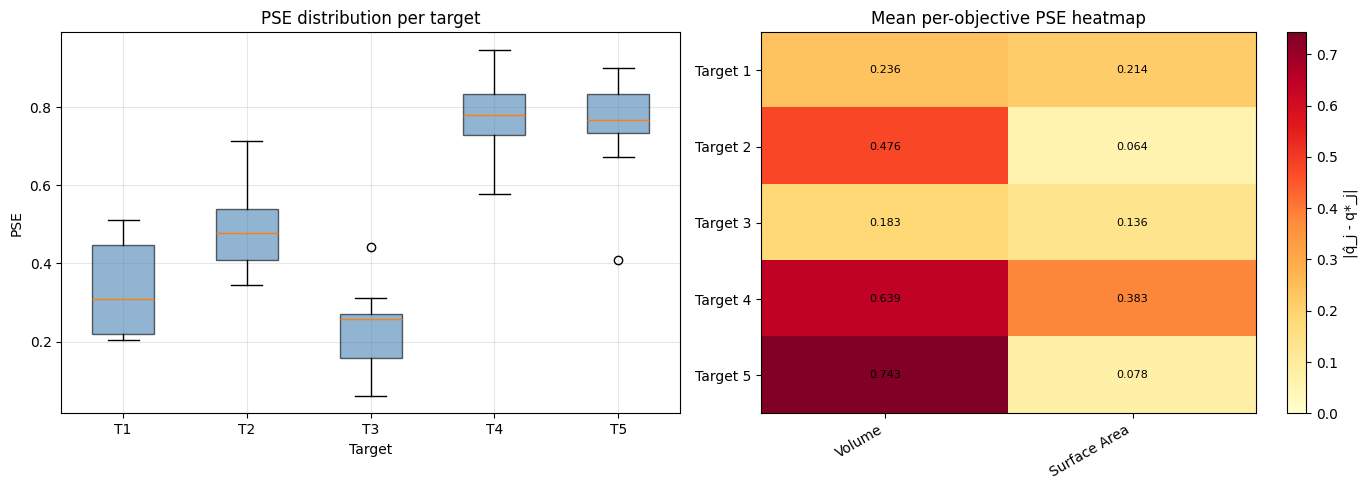

Saved: pse_analysis.png


In [ ]:
# ── Plot 1: PSE per target (box plot across samples) ─────────────────────────
pse_by_target = [
    [row[2] for row in pse_table if row[0] == t_idx]
    for t_idx in range(len(target_properties))
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot(pse_by_target,
                tick_labels=[f'T{i+1}' for i in range(len(target_properties))],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_xlabel('Target')
axes[0].set_ylabel('PSE')
axes[0].set_title('PSE distribution per target')
axes[0].grid(True, alpha=0.3)

# ── Plot 2: per-dimension PSE heatmap ────────────────────────────────────────
# Mean per-dim PSE for each target
pse_pd_by_target = np.zeros((len(target_properties), len(PROP_KEYS)))
for row in pse_table:
    t_idx, s_idx, pse, pse_pd = row
    pse_pd_by_target[t_idx] += pse_pd
pse_pd_by_target /= N_SAMPLES

im = axes[1].imshow(pse_pd_by_target, aspect='auto', cmap='YlOrRd', vmin=0)
axes[1].set_xticks(range(len(PROP_NAMES)))
axes[1].set_xticklabels(PROP_NAMES, rotation=30, ha='right')
axes[1].set_yticks(range(len(target_properties)))
axes[1].set_yticklabels([f'Target {i+1}' for i in range(len(target_properties))])
axes[1].set_title('Mean per-objective PSE heatmap')
plt.colorbar(im, ax=axes[1], label='|q̂_j - q*_j|')

# Annotate cells
for i in range(len(target_properties)):
    for j in range(len(PROP_KEYS)):
        axes[1].text(j, i, f'{pse_pd_by_target[i,j]:.3f}',
                     ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('pse_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pse_analysis.png')

## 13. Latent Space Diversity Analysis

For each target $\mathbf{q}^*$, measure the diversity among the $K$ generated shapes via
mean pairwise Chamfer distance:
$$\mathrm{Div}(\mathbf{q}^*) = \frac{1}{\binom{K}{2}}\sum_{j<k} d_\mathrm{CD}(\hat{P}^{(j)}, \hat{P}^{(k)})$$
A non-zero diversity confirms the latent space has not collapsed.

In [ ]:
def chamfer_distance_np(A, B):
    """Chamfer distance between two (N,3) and (M,3) numpy arrays."""
    from scipy.spatial import cKDTree
    tree_B = cKDTree(B)
    tree_A = cKDTree(A)
    d_AB, _ = tree_B.query(A, k=1)
    d_BA, _ = tree_A.query(B, k=1)
    return float((d_AB**2).mean() + (d_BA**2).mean())


diversity_per_target = []
print(f'{"Target":>8}  {"Diversity (mean pairwise CD)":>30}')
print('-' * 45)

for t_idx in range(len(target_properties)):
    pcs   = all_point_clouds[t_idx]   # (N_SAMPLES, N_POINTS, 3)
    dists = []
    for j in range(N_SAMPLES):
        for k in range(j+1, N_SAMPLES):
            dists.append(chamfer_distance_np(pcs[j], pcs[k]))
    div = float(np.mean(dists)) if dists else 0.0
    diversity_per_target.append(div)
    print(f'{t_idx+1:>8}  {div:>30.6f}')

print(f'\nMean diversity across all targets: {np.mean(diversity_per_target):.6f}')

  Target    Diversity (mean pairwise CD)
---------------------------------------------
       1                        0.007645
       2                        0.006169
       3                        0.006657
       4                        0.006833
       5                        0.004741

Mean diversity across all targets: 0.006409


## 14. Final Summary Table

In [ ]:
print('='*75)
print('STAGE 3 — INVERSE DESIGN SUMMARY')
print('='*75)
print(f'CVAE checkpoint : {CHECKPOINT_PATH}')
print(f'Targets         : {len(target_properties)}')
print(f'Samples / target: {N_SAMPLES}')
print(f'Grid resolution : {GRID_RES}³')
print(f'SDF fit epochs  : {SDF_EPOCHS}')
print()

header = f'{"Target":>8}  {"Mean PSE":>10}  {"Std PSE":>9}  {"Diversity":>12}'
print(header)
print('-' * len(header))

for t_idx in range(len(target_properties)):
    t_pse = [row[2] for row in pse_table if row[0] == t_idx]
    print(f'{t_idx+1:>8}  {np.mean(t_pse):>10.4f}  {np.std(t_pse):>9.4f}  '
          f'{diversity_per_target[t_idx]:>12.6f}')

print('-' * len(header))
print(f'{"OVERALL":>8}  {np.mean(all_pse):>10.4f}  {np.std(all_pse):>9.4f}  '
      f'{np.mean(diversity_per_target):>12.6f}')
print()
print(f'Saved meshes    : {list(MESH_DIR.glob("*.obj"))}')

STAGE 3 — INVERSE DESIGN SUMMARY
CVAE checkpoint : cvae_checkpoint.pt
Targets         : 5
Samples / target: 10
Grid resolution : 128³
SDF fit epochs  : 1000

  Target    Mean PSE    Std PSE     Diversity
---------------------------------------------
       1      0.3327     0.1184      0.007645
       2      0.4832     0.1052      0.006169
       3      0.2341     0.1021      0.006657
       4      0.7645     0.1097      0.006833
       5      0.7509     0.1306      0.004741
---------------------------------------------
 OVERALL      0.5131     0.2431      0.006409

Saved meshes    : [PosixPath('generated_meshes/target3_sample2.obj'), PosixPath('generated_meshes/target5_sample9.obj'), PosixPath('generated_meshes/target1_sample3.obj'), PosixPath('generated_meshes/target5_sample5.obj'), PosixPath('generated_meshes/target2_sample3.obj'), PosixPath('generated_meshes/target1_sample6.obj'), PosixPath('generated_meshes/target5_sample8.obj'), PosixPath('generated_meshes/target2_sample10.obj'),

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import shutil
from google.colab import files

# 1. Zip the entire 'generated_meshes' folder
# The first argument is the name of the zip file we are creating
# The third argument is the folder we want to compress
shutil.make_archive('my_generated_meshes', 'zip', 'generated_meshes')

# 2. Trigger the browser to download the zip file to your local machine
files.download('my_generated_meshes.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>